<a href="https://colab.research.google.com/github/Khulbe-Nitin/Volt-Relay/blob/main/Collab_notebook/abhishek_fourdataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [221]:
from google.colab import files
files.upload()

Saving batteries.csv to batteries (2).csv


{'batteries (2).csv': b'battery_id,pack_type,supplier,manufacturing_lot,manufacture_date,commission_date,rated_capacity_kwh,purchase_cost_inr,initial_soh_pct,bms_firmware,retired_date,retirement_reason,current_soh_pct\nBAT-2W-100000,2W_2.1kWh,Cellora,CE-2503,2025-01-30,2025-03-19,2.1,31018,99.9,BMS-4.1,,,79.5\nBAT-2W-100001,2W_2.1kWh,Cellora,CE-2403,2024-02-27,2024-03-30,2.1,34111,99.2,BMS-4.2,,,79.5\nBAT-3W-100002,3W_4.8kWh,Cellora,CE-2305,2023-04-15,2023-05-11,4.8,66521,99.5,BMS-4.1,,,87.0\nBAT-2W-100003,2W_2.1kWh,Kyron,KY-2409,2024-09-28,2024-10-09,2.1,32753,99.5,BMS-4.1,2025-06-15,end_of_life,58.1\nBAT-2W-100004,2W_2.1kWh,Kyron,KY-2407,2024-11-06,2024-11-21,2.1,31734,99.5,BMS-4.2,2025-06-15,end_of_life,60.6\nBAT-2W-100005,2W_2.1kWh,Cellora,CE-2308,2023-07-18,2023-08-31,2.1,32340,99.2,BMS-4.2,,,80.5\nBAT-2W-100006,2W_2.1kWh,Kyron,KY-2408,2024-09-29,2024-10-20,2.1,31653,99.5,BMS-4.2,2025-06-15,end_of_life,60.5\nBAT-2W-100007,2W_2.1kWh,Cellora,CE-2403,2024-02-25,2024-03-18,2.1,33929,9

# DATA ANYLASIS

In [92]:
df = pd.read_csv("batteries.csv")
df
print(df.shape)
print(df.info())

(6500, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6500 entries, 0 to 6499
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   battery_id          6500 non-null   object 
 1   pack_type           6500 non-null   object 
 2   supplier            6500 non-null   object 
 3   manufacturing_lot   6500 non-null   object 
 4   manufacture_date    6500 non-null   object 
 5   commission_date     6500 non-null   object 
 6   rated_capacity_kwh  6500 non-null   float64
 7   purchase_cost_inr   6500 non-null   int64  
 8   initial_soh_pct     6500 non-null   float64
 9   bms_firmware        6500 non-null   object 
 10  retired_date        1438 non-null   object 
 11  retirement_reason   1438 non-null   object 
 12  current_soh_pct     6500 non-null   float64
dtypes: float64(3), int64(1), object(9)
memory usage: 660.3+ KB
None


In [222]:
df.head()

,battery_id,pack_type,supplier,manufacturing_lot,manufacture_date,commission_date,rated_capacity_kwh,purchase_cost_inr,initial_soh_pct,bms_firmware,retired_date,retirement_reason,current_soh_pct,status
0,BAT-2W-100000,2W_2.1kWh,Cellora,CE-2503,2025-01-30,2025-03-19,2.1,31018,99.9,BMS-4.1,NaT,active,79.5,active
1,BAT-2W-100001,2W_2.1kWh,Cellora,CE-2403,2024-02-27,2024-03-30,2.1,34111,99.2,BMS-4.2,NaT,active,79.5,active
2,BAT-3W-100002,3W_4.8kWh,Cellora,CE-2305,2023-04-15,2023-05-11,4.8,66521,99.5,BMS-4.1,NaT,active,87.0,active
3,BAT-2W-100003,2W_2.1kWh,Kyron,KY-2409,2024-09-28,2024-10-09,2.1,32753,99.5,BMS-4.1,2025-06-15,end_of_life,58.1,retired
4,BAT-2W-100004,2W_2.1kWh,Kyron,KY-2407,2024-11-06,2024-11-21,2.1,31734,99.5,BMS-4.2,2025-06-15,end_of_life,60.6,retired


In [223]:
df.tail()

,battery_id,pack_type,supplier,manufacturing_lot,manufacture_date,commission_date,rated_capacity_kwh,purchase_cost_inr,initial_soh_pct,bms_firmware,retired_date,retirement_reason,current_soh_pct,status
6495,BAT-2W-106495,2W_2.1kWh,Kyron,KY-2408,2024-10-22,2024-11-30,2.1,32313,98.6,BMS-4.1,2025-06-15,end_of_life,61.2,retired
6496,BAT-2W-106496,2W_2.1kWh,Kyron,KY-2409,2024-10-22,2024-11-19,2.1,30867,99.9,BMS-4.0,2025-06-15,end_of_life,63.2,retired
6497,BAT-2W-106497,2W_2.1kWh,Cellora,CE-2412,2024-12-03,2024-12-30,2.1,30607,99.6,BMS-4.1,NaT,active,81.5,active
6498,BAT-2W-106498,2W_2.1kWh,Kyron,KY-2408,2024-11-05,2024-11-22,2.1,31885,100.0,BMS-4.2,2025-06-15,end_of_life,63.5,retired
6499,BAT-2W-106499,2W_2.1kWh,Kyron,KY-2407,2024-09-11,2024-10-29,2.1,33063,98.5,BMS-4.0,2025-06-15,end_of_life,60.4,retired


# FINDING MISSING VALUES AND DUPLICATES

In [224]:
df.isnull().sum()

,0
battery_id,0
pack_type,0
supplier,0
manufacturing_lot,0
manufacture_date,0
commission_date,0
rated_capacity_kwh,0
purchase_cost_inr,0
initial_soh_pct,0
bms_firmware,0


In [225]:
df.dtypes

,0
battery_id,object
pack_type,object
supplier,object
manufacturing_lot,object
manufacture_date,datetime64[ns]
commission_date,datetime64[ns]
rated_capacity_kwh,float64
purchase_cost_inr,int64
initial_soh_pct,float64
bms_firmware,object


In [97]:
df.shape

(6500, 13)

In [98]:
df.size

84500

In [99]:
df.duplicated().sum()


np.int64(0)

In [226]:
df.describe()

,manufacture_date,commission_date,rated_capacity_kwh,purchase_cost_inr,initial_soh_pct,retired_date,current_soh_pct
count,6500,6500,6500.000000,6500.000000,6500.000000,1438,6500.000000
mean,2024-06-08 04:53:19.015384576,2024-07-11 18:50:30.646153728,2.507908,37414.073538,99.191292,2025-06-15 00:00:00.000000256,76.614585
min,2023-01-07 00:00:00,2023-03-01 00:00:00,2.100000,27473.000000,97.800000,2025-06-15 00:00:00,55.400000
25%,2024-01-28 00:00:00,2024-03-07 00:00:00,2.100000,31339.500000,98.900000,2025-06-15 00:00:00,78.400000
50%,2024-08-17 00:00:00,2024-09-19 00:00:00,2.100000,32250.000000,99.200000,2025-06-15 00:00:00,79.800000
75%,2024-10-24 00:00:00,2024-11-25 00:00:00,2.100000,33397.250000,99.500000,2025-06-15 00:00:00,80.800000
max,2025-06-02 00:00:00,2025-06-15 00:00:00,4.800000,75037.000000,100.000000,2025-06-15 00:00:00,88.600000
std,NaN,NaN,0.967009,12951.496627,0.397470,NaN,8.824758


In [101]:
for col in df.select_dtypes(include=["object","string"]).columns:
    s = df[col].dropna().astype(str)
    print(col, (s != s.str.strip()).sum())  # checking the Text columns  extra space

battery_id 0
pack_type 0
supplier 0
manufacturing_lot 0
manufacture_date 0
commission_date 0
bms_firmware 0
retired_date 0
retirement_reason 0


# CELANING THE DATASET

In [102]:
for col in ["manufacture_date", "commission_date", "retired_date"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")
print(df["manufacture_date"].dtype)

datetime64[ns]


In [103]:
df["status"] = df["retired_date"].apply(lambda x: "retired" if pd.notna(x) else "active")


In [104]:
df["retirement_reason"] = df["retirement_reason"].fillna("active")

# CHECKING THE THE LOGICAL ORDER

In [105]:
print((df["commission_date"] < df["manufacture_date"]).sum()) # Retired date commission date ke baad honi chahiye

0


In [106]:
print((df["retired_date"] < df["commission_date"]).sum()) # Retired date commission date ke baad honi chahiye

0


In [107]:
print(((df["current_soh_pct"] < 0) | (df["current_soh_pct"] > 100)).sum()) #SOH (State of Health) percentage 0-100 range me hai kya

0


In [108]:
print((df["current_soh_pct"] > df["initial_soh_pct"]).sum()) #Current SOH kabhi initial SOH se zyada nahi honi chahiye (battery time ke saath degrade hoti hai)

0


In [109]:
print((df["purchase_cost_inr"] <= 0).sum())  # Cost negative ya zero to nahi

0


# EDA PART OF THE DATA

In [207]:
fleet_mix = df.groupby(['pack_type','supplier']).size().unstack(fill_value=0)
fleet_mix['Total'] = fleet_mix.sum(axis=1)
fleet_mix


supplier,Amptek,Cellora,Kyron,Total
pack_type,,,,
2W_2.1kWh,1098,3035,1385,5518
3W_4.8kWh,209,520,253,982


In [213]:
print("Overall status split:")
print(df['status'].value_counts())
print()
print("Retirement rate by supplier:")
print((df.groupby('supplier')['status'].apply(lambda s: (s=='Retired').mean()*100)).round(1).astype(str) + '%')



Overall status split:
status
active     5062
retired    1438
Name: count, dtype: int64

Retirement rate by supplier:
supplier
Amptek     0.0%
Cellora    0.0%
Kyron      0.0%
Name: status, dtype: object


# VISUALIZATION

/tmp/ipykernel_7919/1406585646.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=order, patch_artist=True)


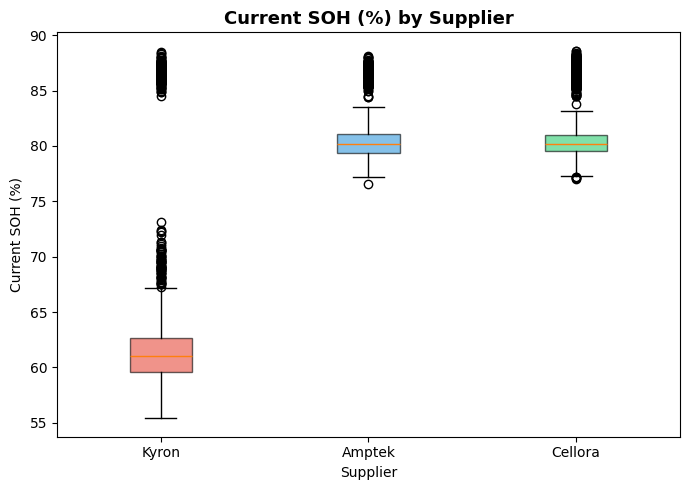

In [215]:
fig, ax = plt.subplots(figsize=(7,5))
order = df.groupby('supplier')['current_soh_pct'].median().sort_values().index
data = [df.loc[df['supplier']==s, 'current_soh_pct'] for s in order]
bp = ax.boxplot(data, labels=order, patch_artist=True)
colors = ['#e74c3c','#3498db','#2ecc71']
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.6)
ax.set_title('Current SOH (%) by Supplier', fontsize=13, fontweight='bold')
ax.set_ylabel('Current SOH (%)')
ax.set_xlabel('Supplier')
plt.tight_layout()
plt.show()

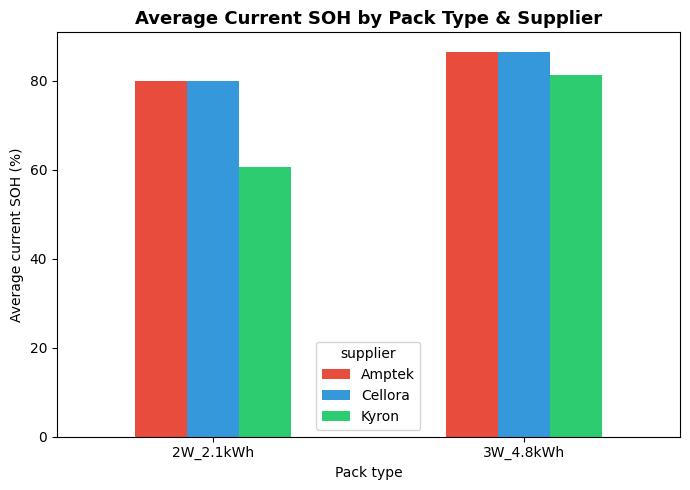

In [219]:
fig, ax = plt.subplots(figsize=(7,5))
pivot = df.groupby(['pack_type','supplier'])['current_soh_pct'].mean().unstack()
pivot.plot(kind='bar', ax=ax, color=colors)
ax.set_title('Average Current SOH by Pack Type & Supplier', fontsize=13, fontweight='bold')
ax.set_ylabel('Average current SOH (%)')
ax.set_xlabel('Pack type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


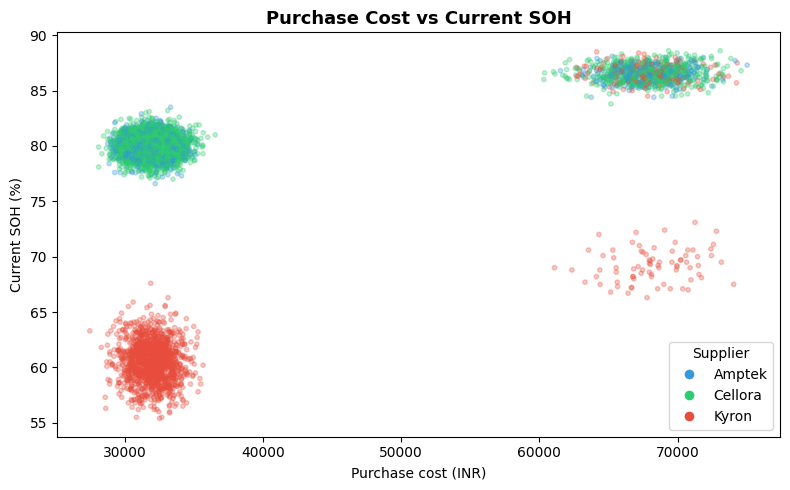

In [220]:
fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(df['purchase_cost_inr'], df['current_soh_pct'], s=10, alpha=0.3, c=df['supplier'].map({'Amptek':'#3498db','Cellora':'#2ecc71','Kyron':'#e74c3c'}))
ax.set_title('Purchase Cost vs Current SOH', fontsize=13, fontweight='bold')
ax.set_xlabel('Purchase cost (INR)')
ax.set_ylabel('Current SOH (%)')
handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=8, label=s)
           for s,c in [('Amptek','#3498db'),('Cellora','#2ecc71'),('Kyron','#e74c3c')]]
ax.legend(handles=handles, title='Supplier')
plt.tight_layout()
plt.show()

# FINAL DATA TYPE CONFIRM AND MISSING VALUES

In [110]:
df["purchase_cost_inr"] = df["purchase_cost_inr"].astype(int)
df["rated_capacity_kwh"] = df["rated_capacity_kwh"].astype(float)
print(df.dtypes)

battery_id                    object
pack_type                     object
supplier                      object
manufacturing_lot             object
manufacture_date      datetime64[ns]
commission_date       datetime64[ns]
rated_capacity_kwh           float64
purchase_cost_inr              int64
initial_soh_pct              float64
bms_firmware                  object
retired_date          datetime64[ns]
retirement_reason             object
current_soh_pct              float64
status                        object
dtype: object


In [227]:
df.isnull().sum()

,0
battery_id,0
pack_type,0
supplier,0
manufacturing_lot,0
manufacture_date,0
commission_date,0
rated_capacity_kwh,0
purchase_cost_inr,0
initial_soh_pct,0
bms_firmware,0


In [112]:
df.to_csv("batteries_cleaned.csv", index=False)

# CITY DAILY DATASET

In [228]:
from google.colab import files
files.upload()

Saving city_daily_context.csv to city_daily_context (2).csv


{'city_daily_context (2).csv': b'city,date,max_temp_c,min_temp_c,rainfall_mm,heat_alert,flood_disruption,festival_or_event,is_public_holiday,grid_outage_hours,competitor_promo_active,ecommerce_sale_event\nBengaluru,2024-01-01,16.7,6.7,0.0,False,False,,False,0.0,False,False\nBengaluru,2024-01-02,17.3,4.6,1.8,False,False,,False,0.2,False,False\nBengaluru,2024-01-03,13.9,6.9,0.7,False,False,,False,0.0,False,False\nBengaluru,2024-01-04,17.9,4.0,2.2,False,False,,False,0.1,False,False\nBengaluru,2024-01-05,16.0,7.8,2.0,False,False,,False,0.0,False,False\nBengaluru,2024-01-06,17.6,7.9,0.0,False,False,,False,0.1,False,False\nBengaluru,2024-01-07,17.2,8.2,0.0,False,False,,False,0.1,False,False\nBengaluru,2024-01-08,16.6,4.9,0.3,False,False,,False,0.3,False,False\nBengaluru,2024-01-09,16.8,8.2,0.0,False,False,,False,0.1,False,False\nBengaluru,2024-01-10,17.0,7.2,1.0,False,False,,False,0.2,False,False\nBengaluru,2024-01-11,16.8,5.6,0.0,False,False,,False,0.0,False,False\nBengaluru,2024-01-12,18.5

In [230]:
df2= pd.read_csv("city_daily_context.csv")

#FINDING MISSING VALUES

In [231]:
df2.isnull().sum()

,0
city,0
date,0
max_temp_c,0
min_temp_c,0
rainfall_mm,0
heat_alert,0
flood_disruption,0
festival_or_event,3172
is_public_holiday,0
grid_outage_hours,0


In [232]:
df2.shape

(3282, 12)

In [233]:
df2.size

39384

In [234]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   city                     3282 non-null   object 
 1   date                     3282 non-null   object 
 2   max_temp_c               3282 non-null   float64
 3   min_temp_c               3282 non-null   float64
 4   rainfall_mm              3282 non-null   float64
 5   heat_alert               3282 non-null   bool   
 6   flood_disruption         3282 non-null   bool   
 7   festival_or_event        110 non-null    object 
 8   is_public_holiday        3282 non-null   bool   
 9   grid_outage_hours        3282 non-null   float64
 10  competitor_promo_active  3282 non-null   bool   
 11  ecommerce_sale_event     3282 non-null   bool   
dtypes: bool(5), float64(4), object(3)
memory usage: 195.6+ KB


In [235]:
df2.duplicated().sum() # zero duplicates values

np.int64(0)

In [236]:
df2.dtypes

,0
city,object
date,object
max_temp_c,float64
min_temp_c,float64
rainfall_mm,float64
heat_alert,bool
flood_disruption,bool
festival_or_event,object
is_public_holiday,bool
grid_outage_hours,float64


#CLEANING PART OF THE DATA

In [237]:
df2['date'] = pd.to_datetime(df2['date'])

In [238]:
df2["festival_or_event"] = df2["festival_or_event"].fillna("No Event")

# EDA PART OF THE DATA

In [247]:
print("Flag frequency (share of all city-days where True):")
flag_cols = ['heat_alert','flood_disruption','is_public_holiday','competitor_promo_active','ecommerce_sale_event']
(df2[flag_cols].mean() * 100).round(2).to_frame('pct_of_days_True')

Flag frequency (share of all city-days where True):


,pct_of_days_True
heat_alert,4.57
flood_disruption,0.21
is_public_holiday,0.55
competitor_promo_active,2.62
ecommerce_sale_event,1.83


In [248]:
df2.groupby('city')[['max_temp_c','min_temp_c','rainfall_mm']].mean().round(1)

,max_temp_c,min_temp_c,rainfall_mm
city,,,
Bengaluru,24.6,9.9,4.7
Delhi NCR,25.3,10.3,5.2
Hyderabad,26.9,11.0,4.5
Jaipur,25.8,10.2,4.7
Mumbai,25.9,12.6,11.4
Pune,23.9,10.3,4.5


In [249]:
df2['festival_or_event'].value_counts()

,count
festival_or_event,
No Event,3172
Big Sale,60
Diwali week,30
Holi,12
Diwali,6
Ganesh Chaturthi,2


# VISUALIZATIONS

KeyError: 'city'

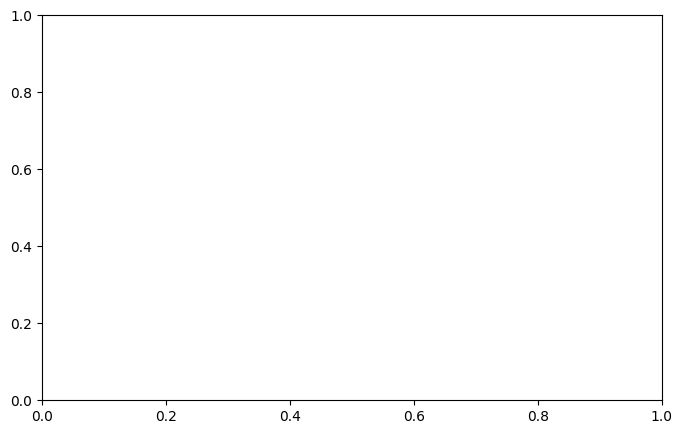

# RECHECKING THE VALUES AFTER CLEANING

In [250]:
df2.isnull().sum()

,0
city,0
date,0
max_temp_c,0
min_temp_c,0
rainfall_mm,0
heat_alert,0
flood_disruption,0
festival_or_event,0
is_public_holiday,0
grid_outage_hours,0


In [125]:
print(df2["date"].dtype)

datetime64[ns]


# station_hourly_status NEW DATASET

In [130]:
df3=pd.read_csv("station_hourly_status.csv")
df3

,station_id,hour_start,charged_2w_avg,charged_2w_min,charged_3w_min,packs_charging,packs_quarantined,chargers_online,ambient_temp_c,cabinet_temp_c,avg_charge_minutes,outage_minutes,grid_kwh,telemetry_status
0,STN-BLR-001,2024-01-01 00:00:00,6.29,6.0,4.0,1.0,0.0,18,8.2,13.5,92.6,0,1.86,ok
1,STN-BLR-001,2024-01-01 01:00:00,8.10,8.0,4.0,8.0,0.0,18,8.2,11.5,88.0,0,13.96,ok
2,STN-BLR-001,2024-01-01 02:00:00,10.56,8.0,4.0,5.0,0.0,18,8.2,12.9,80.2,0,8.27,ok
3,STN-BLR-001,2024-01-01 03:00:00,7.44,6.0,3.0,5.0,0.0,18,8.2,13.2,86.7,0,8.38,ok
4,STN-BLR-001,2024-01-01 04:00:00,9.18,7.0,3.0,3.0,0.0,18,8.2,14.0,83.9,0,4.28,ok
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1487707,STN-TST-02,2025-06-30 19:00:00,6.23,6.0,NaN,3.0,0.0,8,30.2,39.2,66.2,0,5.85,ok
1487708,STN-TST-02,2025-06-30 20:00:00,6.48,6.0,NaN,2.0,0.0,8,28.3,34.0,57.1,0,3.82,ok
1487709,STN-TST-02,2025-06-30 21:00:00,7.32,7.0,NaN,3.0,0.0,8,18.0,23.9,65.0,0,6.09,ok
1487710,STN-TST-02,2025-06-30 22:00:00,5.20,3.0,NaN,1.0,0.0,8,18.0,24.9,68.5,0,1.72,ok


# FINDING MISSING VALUES AND DUPLICATES VALUES

In [131]:
df3.isnull().sum()

,0
station_id,0
hour_start,0
charged_2w_avg,9384
charged_2w_min,9384
charged_3w_min,821808
packs_charging,9384
packs_quarantined,9384
chargers_online,0
ambient_temp_c,9384
cabinet_temp_c,9384


In [141]:
df3.head()

,station_id,hour_start,charged_2w_avg,charged_2w_min,charged_3w_min,packs_charging,packs_quarantined,chargers_online,ambient_temp_c,cabinet_temp_c,avg_charge_minutes,outage_minutes,grid_kwh,telemetry_status
0,STN-BLR-001,2024-01-01 00:00:00,6.29,6.0,4.0,1.0,0.0,18,8.2,13.5,92.6,0,1.86,ok
1,STN-BLR-001,2024-01-01 01:00:00,8.10,8.0,4.0,8.0,0.0,18,8.2,11.5,88.0,0,13.96,ok
2,STN-BLR-001,2024-01-01 02:00:00,10.56,8.0,4.0,5.0,0.0,18,8.2,12.9,80.2,0,8.27,ok
3,STN-BLR-001,2024-01-01 03:00:00,7.44,6.0,3.0,5.0,0.0,18,8.2,13.2,86.7,0,8.38,ok
4,STN-BLR-001,2024-01-01 04:00:00,9.18,7.0,3.0,3.0,0.0,18,8.2,14.0,83.9,0,4.28,ok


In [140]:
df3.tail()

,station_id,hour_start,charged_2w_avg,charged_2w_min,charged_3w_min,packs_charging,packs_quarantined,chargers_online,ambient_temp_c,cabinet_temp_c,avg_charge_minutes,outage_minutes,grid_kwh,telemetry_status
1487707,STN-TST-02,2025-06-30 19:00:00,6.23,6.0,NaN,3.0,0.0,8,30.2,39.2,66.2,0,5.85,ok
1487708,STN-TST-02,2025-06-30 20:00:00,6.48,6.0,NaN,2.0,0.0,8,28.3,34.0,57.1,0,3.82,ok
1487709,STN-TST-02,2025-06-30 21:00:00,7.32,7.0,NaN,3.0,0.0,8,18.0,23.9,65.0,0,6.09,ok
1487710,STN-TST-02,2025-06-30 22:00:00,5.20,3.0,NaN,1.0,0.0,8,18.0,24.9,68.5,0,1.72,ok
1487711,STN-TST-02,2025-06-30 23:00:00,4.98,2.0,NaN,3.0,0.0,8,18.0,24.4,67.1,0,5.79,ok


In [142]:
df3.shape

(1487712, 14)

In [143]:
df3.size

20827968

In [145]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1487712 entries, 0 to 1487711
Data columns (total 14 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   station_id          1487712 non-null  object 
 1   hour_start          1487712 non-null  object 
 2   charged_2w_avg      1478328 non-null  float64
 3   charged_2w_min      1478328 non-null  float64
 4   charged_3w_min      665904 non-null   float64
 5   packs_charging      1478328 non-null  float64
 6   packs_quarantined   1478328 non-null  float64
 7   chargers_online     1487712 non-null  int64  
 8   ambient_temp_c      1478328 non-null  float64
 9   cabinet_temp_c      1478328 non-null  float64
 10  avg_charge_minutes  1478328 non-null  float64
 11  outage_minutes      1487712 non-null  int64  
 12  grid_kwh            1478328 non-null  float64
 13  telemetry_status    1487712 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 158.9+ MB


In [146]:
df3.duplicated().sum()

np.int64(0)

# CELANING PART OF DATA

In [159]:
df3["hour_start"] = pd.to_datetime(df3["hour_start"])
print(df3["hour_start"].dtype)

datetime64[ns]


In [158]:
df3 = df3.drop_duplicates(subset=["station_id", "hour_start"])
df3

,station_id,hour_start,charged_2w_avg,charged_2w_min,charged_3w_min,packs_charging,packs_quarantined,chargers_online,ambient_temp_c,cabinet_temp_c,avg_charge_minutes,outage_minutes,grid_kwh,telemetry_status,has_data
0,STN-BLR-001,2024-01-01 00:00:00,6.29,6.0,4.0,1.0,0.0,18,8.2,13.5,92.6,0,1.86,ok,True
1,STN-BLR-001,2024-01-01 01:00:00,8.10,8.0,4.0,8.0,0.0,18,8.2,11.5,88.0,0,13.96,ok,True
2,STN-BLR-001,2024-01-01 02:00:00,10.56,8.0,4.0,5.0,0.0,18,8.2,12.9,80.2,0,8.27,ok,True
3,STN-BLR-001,2024-01-01 03:00:00,7.44,6.0,3.0,5.0,0.0,18,8.2,13.2,86.7,0,8.38,ok,True
4,STN-BLR-001,2024-01-01 04:00:00,9.18,7.0,3.0,3.0,0.0,18,8.2,14.0,83.9,0,4.28,ok,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1487707,STN-TST-02,2025-06-30 19:00:00,6.23,6.0,NaN,3.0,0.0,8,30.2,39.2,66.2,0,5.85,ok,True
1487708,STN-TST-02,2025-06-30 20:00:00,6.48,6.0,NaN,2.0,0.0,8,28.3,34.0,57.1,0,3.82,ok,True
1487709,STN-TST-02,2025-06-30 21:00:00,7.32,7.0,NaN,3.0,0.0,8,18.0,23.9,65.0,0,6.09,ok,True
1487710,STN-TST-02,2025-06-30 22:00:00,5.20,3.0,NaN,1.0,0.0,8,18.0,24.9,68.5,0,1.72,ok,True


In [157]:
df3["has_data"] = df3["telemetry_status"] != "missing"    #telemetry_status = "missing" ka matlab hai sensor se data hi nahi aaya — is row ko delete nahi karna, bas flag laga do taaki pata chale ye row "real data" hai ya nahi:
df3["has_data"]

,has_data
0,True
1,True
2,True
3,True
4,True
...,...
1487707,True
1487708,True
1487709,True
1487710,True


In [161]:
df3.isnull().sum()

,0
station_id,0
hour_start,0
charged_2w_avg,9384
charged_2w_min,9384
charged_3w_min,821808
packs_charging,9384
packs_quarantined,9384
chargers_online,0
ambient_temp_c,9384
cabinet_temp_c,9384


In [163]:
df3 = df3.sort_values(["station_id", "hour_start"])

# sensor wale numeric columns - station ke andar pichli/agli reading se bharo
sensor_cols = ["charged_2w_avg","charged_2w_min","packs_charging","packs_quarantined",
               "ambient_temp_c","cabinet_temp_c","avg_charge_minutes","grid_kwh"]
for col in sensor_cols:
    df3[col] = df3.groupby("station_id")[col].ffill()
    df3[col] = df3.groupby("station_id")[col].bfill()

# charged_3w_min - null matlab 3-wheeler charging hi nahi hui, 0 se bharo
df3["charged_3w_min"] = df3["charged_3w_min"].fillna(0)

In [165]:
df3.isnull().sum()

,0
station_id,0
hour_start,0
charged_2w_avg,0
charged_2w_min,0
charged_3w_min,0
packs_charging,0
packs_quarantined,0
chargers_online,0
ambient_temp_c,0
cabinet_temp_c,0


# support_tickets

In [175]:
from google.colab import files
files.upload()

Saving support_tickets.csv to support_tickets.csv


{'support_tickets.csv': b'ticket_id,rider_id,station_id,battery_id,created_ts,channel,category,rider_comment,priority,resolution_status,resolution_hours,csat_score\r\nTK-0000001,RD-1001097,STN-BLR-016,,2024-01-01 17:44:05,call_center,billing_dispute,amount galat kata hai is baar,low,duplicate,,\r\nTK-0000002,RD-1001216,STN-BLR-020,BAT-2W-104489,2024-01-01 22:59:14,partner_escalation,long_queue,queue itna lamba tha ki late ho gaya delivery mein,medium,resolved,5.2,\r\nTK-0000003,RD-1001631,STN-JAI-140,BAT-2W-102867,2024-01-01 19:20:12,app_chat,long_queue,queue itna lamba tha ki late ho gaya delivery mein,medium,resolved,16.3,\r\nTK-0000004,RD-1002086,STN-DEL-039,BAT-2W-102727,2024-01-01 03:14:33,partner_escalation,long_queue,queue itna lamba tha ki late ho gaya delivery mein,high,resolved,4.4,3\r\nTK-0000005,RD-1002308,STN-BLR-004,BAT-2W-105975,2024-01-02 01:47:49,app_chat,other,scooter weak lag raha hai aajkal,low,resolved,23.3,1\r\nTK-0000006,RD-1002329,,,2024-01-02 01:21:18,whatsapp,

In [178]:
df4=pd.read_csv('support_tickets.csv')
df4

,ticket_id,rider_id,station_id,battery_id,created_ts,channel,category,rider_comment,priority,resolution_status,resolution_hours,csat_score
0,TK-0000001,RD-1001097,STN-BLR-016,NaN,2024-01-01 17:44:05,call_center,billing_dispute,amount galat kata hai is baar,low,duplicate,NaN,NaN
1,TK-0000002,RD-1001216,STN-BLR-020,BAT-2W-104489,2024-01-01 22:59:14,partner_escalation,long_queue,queue itna lamba tha ki late ho gaya delivery ...,medium,resolved,5.2,NaN
2,TK-0000003,RD-1001631,STN-JAI-140,BAT-2W-102867,2024-01-01 19:20:12,app_chat,long_queue,queue itna lamba tha ki late ho gaya delivery ...,medium,resolved,16.3,NaN
3,TK-0000004,RD-1002086,STN-DEL-039,BAT-2W-102727,2024-01-01 03:14:33,partner_escalation,long_queue,queue itna lamba tha ki late ho gaya delivery ...,high,resolved,4.4,3.0
4,TK-0000005,RD-1002308,STN-BLR-004,BAT-2W-105975,2024-01-02 01:47:49,app_chat,other,scooter weak lag raha hai aajkal,low,resolved,23.3,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
43995,TK-0043996,RD-1019800,STN-PUN-104,NaN,2025-06-30 14:26:49,app_chat,app_issue,app not showing nearby stations,low,unresolved,NaN,NaN
43996,TK-0043997,RD-1019803,STN-HYD-079,BAT-2W-102012,2025-06-30 12:24:01,whatsapp,low_range,"battry discharge fast ho raha hai, gaadi mein ...",low,resolved,23.4,5.0
43997,TK-0043998,RD-1019812,STN-JAI-141,NaN,2025-06-30 13:10:06,app_chat,low_range,kal se range kam ho gaya hai battery ka,medium,resolved,10.1,NaN
43998,TK-0043999,RD-1019838,STN-DEL-059,NaN,2025-06-30 14:39:41,whatsapp,other,general issue with the vehicle performance,low,resolved,22.2,1.0


# DATA UNDERSTANDING

In [183]:
print("Shape:", df4.shape)
df4.head()

Shape: (44000, 12)


,ticket_id,rider_id,station_id,battery_id,created_ts,channel,category,rider_comment,priority,resolution_status,resolution_hours,csat_score
0,TK-0000001,RD-1001097,STN-BLR-016,NaN,2024-01-01 17:44:05,call_center,billing_dispute,amount galat kata hai is baar,low,duplicate,NaN,NaN
1,TK-0000002,RD-1001216,STN-BLR-020,BAT-2W-104489,2024-01-01 22:59:14,partner_escalation,long_queue,queue itna lamba tha ki late ho gaya delivery ...,medium,resolved,5.2,NaN
2,TK-0000003,RD-1001631,STN-JAI-140,BAT-2W-102867,2024-01-01 19:20:12,app_chat,long_queue,queue itna lamba tha ki late ho gaya delivery ...,medium,resolved,16.3,NaN
3,TK-0000004,RD-1002086,STN-DEL-039,BAT-2W-102727,2024-01-01 03:14:33,partner_escalation,long_queue,queue itna lamba tha ki late ho gaya delivery ...,high,resolved,4.4,3.0
4,TK-0000005,RD-1002308,STN-BLR-004,BAT-2W-105975,2024-01-02 01:47:49,app_chat,other,scooter weak lag raha hai aajkal,low,resolved,23.3,1.0


In [184]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44000 entries, 0 to 43999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ticket_id          44000 non-null  object 
 1   rider_id           44000 non-null  object 
 2   station_id         41773 non-null  object 
 3   battery_id         30765 non-null  object 
 4   created_ts         44000 non-null  object 
 5   channel            44000 non-null  object 
 6   category           44000 non-null  object 
 7   rider_comment      44000 non-null  object 
 8   priority           44000 non-null  object 
 9   resolution_status  44000 non-null  object 
 10  resolution_hours   37888 non-null  float64
 11  csat_score         15129 non-null  float64
dtypes: float64(2), object(10)
memory usage: 4.0+ MB


In [185]:
print("Missing values per column:")
print(df4.isna().sum())

Missing values per column:
ticket_id                0
rider_id                 0
station_id            2227
battery_id           13235
created_ts               0
channel                  0
category                 0
rider_comment            0
priority                 0
resolution_status        0
resolution_hours      6112
csat_score           28871
dtype: int64


In [186]:
print("Unique values in key categorical columns:\n")
for col in ['channel', 'category', 'priority', 'resolution_status']:
    print(f"{col}: {df4[col].unique().tolist()}")

Unique values in key categorical columns:

channel: ['call_center', 'partner_escalation', 'app_chat', 'whatsapp']
category: ['billing_dispute', 'long_queue', 'other', 'no_battery_available', 'app_issue', 'low_range']
priority: ['low', 'medium', 'high']
resolution_status: ['duplicate', 'resolved', 'unresolved']


In [187]:
print("Numeric column summary:")
df4[['resolution_hours', 'csat_score']].describe()

Numeric column summary:


,resolution_hours,csat_score
count,37888.000000,15129.000000
mean,15.951840,3.559720
std,11.004491,1.305327
min,0.900000,1.000000
25%,8.500000,3.000000
50%,13.200000,4.000000
75%,20.200000,5.000000
max,155.800000,5.000000


# DATA CLEANING

In [188]:
# 2.1 - date column ko proper datetime banao
df4['created_ts'] = pd.to_datetime(df4['created_ts'])
print(df4['created_ts'].dtype)

datetime64[ns]


In [189]:
# 2.2 - duplicate check
print("Full row duplicates:", df4.duplicated().sum())
print("ticket_id duplicates:", df4['ticket_id'].duplicated().sum())

Full row duplicates: 0
ticket_id duplicates: 0


In [190]:
# 2.3 - whitespace check on text columns
for col in df4.select_dtypes(include=['object', 'string']).columns:
    s = df4[col].dropna().astype(str)
    issues = (s != s.str.strip()).sum()
    if issues:

        print(col, "has", issues, "rows with extra whitespace")
print("Whitespace check done - no output above means all clean.")

Whitespace check done - no output above means all clean.


# FILLNA MISSING VALUES

In [191]:
# 2.4 - verify resolution_hours null matches unresolved+duplicate tickets
check = df4.groupby('resolution_status')['resolution_hours'].apply(lambda x: x.isna().sum())
print(check)

resolution_status
duplicate      937
resolved         0
unresolved    5175
Name: resolution_hours, dtype: int64


In [192]:
# 2.5 - station_id / battery_id ke null ko meaningful label do (text column hai, isliye)
df4['station_id'] = df4['station_id'].fillna('Not Linked')
df4['battery_id'] = df4['battery_id'].fillna('Not Linked')

# resolution_hours aur csat_score numeric hain aur null genuinely "not applicable" hai -
# inhe waisa hi (NaN) rehne dete hain taaki average nikalte waqt automatically ignore ho jayein
print("Final missing value check:")
print(df4.isna().sum())

Final missing value check:
ticket_id                0
rider_id                 0
station_id               0
battery_id               0
created_ts               0
channel                  0
category                 0
rider_comment            0
priority                 0
resolution_status        0
resolution_hours      6112
csat_score           28871
dtype: int64


#Exploratory Data Anyalysis

In [193]:
print("Ticket count by category:")
print(df4['category'].value_counts())

Ticket count by category:
category
no_battery_available    11647
other                    9484
low_range                6636
app_issue                5787
long_queue               5731
billing_dispute          4715
Name: count, dtype: int64


In [194]:
print("Ticket count by category:")
print(df4['category'].value_counts())

Ticket count by category:
category
no_battery_available    11647
other                    9484
low_range                6636
app_issue                5787
long_queue               5731
billing_dispute          4715
Name: count, dtype: int64


In [195]:
print("Ticket count by priority:")
print(df4['priority'].value_counts())

Ticket count by priority:
priority
medium    19884
low       17649
high       6467
Name: count, dtype: int64


In [196]:
print("Resolution status breakdown (%):")
print((df4['resolution_status'].value_counts(normalize=True) * 100).round(1))

Resolution status breakdown (%):
resolution_status
resolved      86.1
unresolved    11.8
duplicate      2.1
Name: proportion, dtype: float64


In [197]:
print("Resolution hours summary (resolved tickets only):")
df4[df4['resolution_status']=='resolved']['resolution_hours'].describe()

Resolution hours summary (resolved tickets only):


,resolution_hours
count,37888.000000
mean,15.951840
std,11.004491
min,0.900000
25%,8.500000
50%,13.200000
75%,20.200000
max,155.800000


In [198]:
print("CSAT score summary (rated tickets only):")
df4['csat_score'].describe()

CSAT score summary (rated tickets only):


,csat_score
count,15129.000000
mean,3.559720
std,1.305327
min,1.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,5.000000


#VISUALTIONS





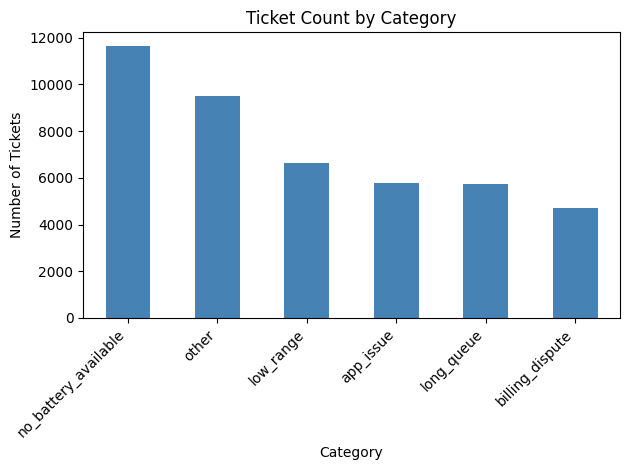

In [199]:
df4['category'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Ticket Count by Category')
plt.ylabel('Number of Tickets')
plt.xlabel('Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

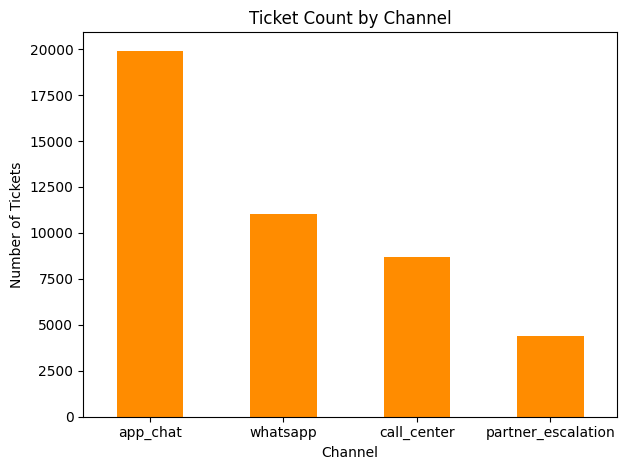

In [200]:
df4['channel'].value_counts().plot(kind='bar', color='darkorange')
plt.title('Ticket Count by Channel')
plt.ylabel('Number of Tickets')
plt.xlabel('Channel')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

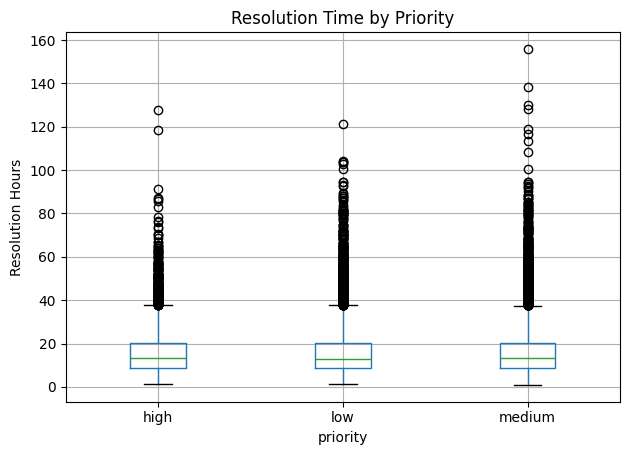

In [204]:
df4.boxplot(column='resolution_hours', by='priority')
plt.title('Resolution Time by Priority')
plt.suptitle('')
plt.ylabel('Resolution Hours')
plt.tight_layout()
plt.show()

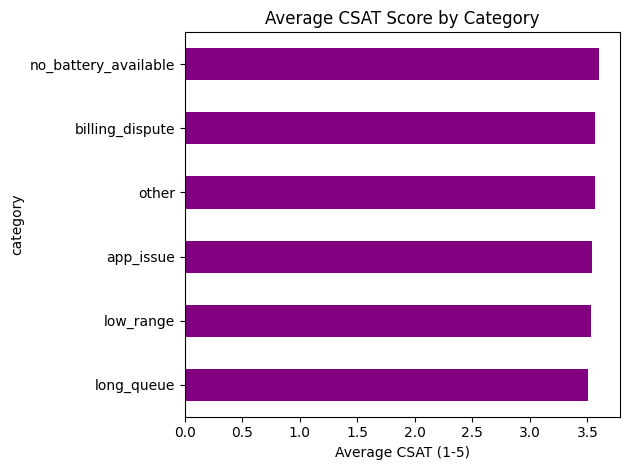

In [205]:
avg_csat = df4.groupby('category')['csat_score'].mean().sort_values()
avg_csat.plot(kind='barh', color='purple')
plt.title('Average CSAT Score by Category')
plt.xlabel('Average CSAT (1-5)')
plt.tight_layout()
plt.show()